# Practical 2 : Generative and Discriminative Models


In this practical, we will compare the Naïve Bayes Classifier (NBC) and Logistic Regression on several
datasets. As part of the practical you should read briefly the following paper:



**On Discriminative vs. Generative classifiers: A comparison of logistic regression
and naive Bayes**  
*Andrew Y. Ng and Michael I. Jordan*  
Advances in Neural Information Processing Systems (NIPS) 2001.

The paper is available on OLAT. 

You should read the Introduction and the Experiments sections. The goal of this practical is
to qualitatively reproduce some of the experimental results in this paper. You are strongly
encouraged to read the rest of the paper, which is rather short and straightforward to read,
though some of you may want to skip the formal proofs.

## Naïve Bayes Classifier (NBC)

You should implement a Naïve Bayes Classifier from scartch using NumPy. To keep your code tidy,
we recommend implementing it as a class. 
The classifier should be able to handle binary and continuous features. 
To earn the bonus points, the classifier should be able to handle categorical features as well. 
Suppose the data has 3
different features, the first being binary, the second being continuous and the third being categorical. Write an implementation that you can initialise as follows:

    nbc = NBC(feature_types=['b', 'r', 'c'])

Along the lines of classifiers provided in sklearn, you want to implement two more functions,
**fit** and **predict**. 
Recall the joint distribution of a generative model: $p(\mathbf{x}, y \mid \theta, \pi) = p(y \mid \pi) \cdot p(\mathbf{x} \mid y, \theta)$.
The **fit** function is to estimate all the parameters ($\theta$ and $\pi$) of the NBC, i.e., train the classifier. The **predict** function is to compute the probabilities that the new input belongs to all classes and
then return the class that has the largest probability, i.e., make the prediction.

    nbc.fit(X_train, y_train)
    ypredicted = nbc.predict(X_test)
    test_accuracy = np.mean(ypredicted == ytest)

Here we import the libraries. 

In [1]:
%matplotlib inline
import pylab
pylab.rcParams['figure.figsize'] = (10., 10.)

import pickle as cp
import matplotlib.pyplot as plt
import numpy as np

### Class-conditional distributions

Before implementing NBC, we first implement the class-conditional distributions $p(\mathbf{x} \mid y, \theta)$. Your implementation should have two functions: **estimate** and **get_log_probability**. 

- The **estimate** function takes data as input and models the data using some distribution $p(x \mid \theta)$, where $\theta$ is the parameters of this distribution. The function estimates the parameters $\theta$ using maximum likelihood estimators (MLE). 
For example, in the case of continuous features, we use the Gaussian distribution to model the data. The estimate function will find the parameters $\mu$ and $\sigma$ for the Gaussian distribution with respect to the input data. 

- The **get_log_probability** function takes as input a new data point $x_{new}$ and returns the log of $p(x_{new} \mid \theta)$. For the Gaussian distribution, the function get_probability will return $\mathcal{N}(x_{new} \mid \mu, \sigma)$. 

For different types of features, you need to use different distributions.
You can import statistic libraries (e.g., `scipy.stats`) for the implementation of the distributions. 

- For **continuous features**: Use Gaussian distribution
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
- For **binary features**: Use Bernoulli distribution 
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html
- For **categorical features**: Use Multinoulli distribution (The multinoulli distribution is a special case of the multinomial distribution, where the number of trials is 1)
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multinomial.html



**Implementation Issues:**
- The probabilities can be very small. To avoid underflow issues, you should compute the log of the probabilities. Read more: (Mur) Chapter 3.5.3 / Lecture Notes
- The standard deviation for Gaussian distributions should never be exactly 0, so in
case your calculated standard deviation is 0, you may want to set it to a small value such as 1e − 6. This is to ensure that your code never encounters division by zero or
taking logarithms of 0 errors. 
For this practical, please set the small value to 1e-6.
- Laplace/Additive smoothing: You want to ensure that the estimates for the parameter for the Bernoulli and Multinoulli random variables is never exactly 0 or 1. For this reason you should consider using Laplace smoothing (https://en.wikipedia.org/wiki/Additive_smoothing).
For this practical, please set alpha to 1.
- We will check the correctness of your implementation using the tests below.
- For simplicity, you can assume the data values for binary features are integers from {0,1} and the data for a categorical feature with M categories are integers from {0, ..., M-1}.
- Fell free to add auxiliary functions or change the parameters of the functions. If you change the parameters of the functions, make sure you change the tests accordingly, so we can test your code.


In [2]:
from scipy.stats import norm, bernoulli, multinomial
ALPHA = 1.0 # for additive smoothing

# Distribution for continuous features
class ContFeatureParam:
    
    def estimate(self, X):

        # Mean and SD for Gaussian Distribution
        self.mean = np.mean(X)
        std = np.std(X)

        # Setting smallest value of SD
        self.std = max(std, 1e-6)

    def get_log_probability(self, X_new):

        # Log density for Gaussian Distribution
        return norm.logpdf(X_new, loc=self.mean, scale=self.std)

# Distribution for binary features
class BinFeatureParam:
    
    def estimate(self, X):

        # X is a vector with binary values {0,1}
        n0 = np.sum(X==0)
        n1 = np.sum(X==1)

        # Laplace Smoothing
        self.p = (n1 + ALPHA)/ (n1 + n0 + 2 * ALPHA)

        # avoid p=0 and p=1
        self.p = min(max(self.p, 1e-12), 1 - 1e-12)

    def get_log_probability(self, X_new):

        # Log Probability Mass Function of Bernoulli
        return bernoulli.logpmf(X_new, self.p)

# Distribution for categorical features
class CatFeatureParam:
    
    # we need to know the number of categories for the categorical feature
    def __init__(self, num_of_categories):
        self._num_of_categories = num_of_categories
    
    def estimate(self, X):

        # count occurences of each category
        counts = np.bincount(X, minlength = self._num_of_categories)

        # Laplace Smoothing
        self.probs = (counts + ALPHA)/ (np.sum(counts) + ALPHA * self._num_of_categories)

        # avoid probability = 0 and = 1 (using a different method than above (nested min max))
        self.probs = np.clip(self.probs, 1e-12, 1 - 1e-12)
         
    def get_log_probability(self, X_new):

        # Multinoulli means Multinomial with n=1
        # convert category index to numerical using OneHot encoding
        one_hot = np.eye(self._num_of_categories)[X_new]
        return multinomial.logpmf(one_hot, n=1, p=self.probs)
        

**Tests:**
    
We will use the code below to test the correctness of your code.

In [3]:
# continuous features

X = np.array([2.70508547,2.10499698,1.76019132,3.42016431,3.47037973,3.67435061,1.84749286,4.3388506,2.27818252,4.65165335])

param = ContFeatureParam()
param.estimate(X)
probs = param.get_log_probability(np.array([0,1,2,3]))
print(probs)

[-5.64670664 -3.02757918 -1.44567455 -0.90099277]


In [4]:
# binary features

X = np.array([0,0,1,1,0,1,0,1,1,1])

param = BinFeatureParam()
param.estimate(X)
probs = param.get_log_probability(np.array([0,1]))
print(probs)

[-0.87546874 -0.5389965 ]


In [5]:
# categorical features (bonus task)

X = np.array([0,6,5,4,0,6,6,4,1,1,2,3,8,8,1,6,4,9,0,2,2,3,8,0,2])

param = CatFeatureParam(num_of_categories=10)
param.estimate(X)
probs = param.get_log_probability(np.array([0,1,2,3,4,5,6,7,8,9]))
print(probs)

[-1.94591015 -2.1690537  -1.94591015 -2.45673577 -2.1690537  -2.86220088
 -1.94591015 -3.55534806 -2.1690537  -2.86220088]


### Implement NBC

We are now ready to implement NBC. We follow the structure of models in scikit-learn. We implement NBC as a class with functions **init**, **fit** and **predict**.
The **init** function takes as input the types of features and initialise the classifier. The **fit** function takes the training data as input and estimates the parameters. The **predict** function predicts the label for the input data. 

**Implementation Issues:**
- You should use matrix operations rather than loops. In general, loops over classes or features are OK, but loops over the rows of data are not a good idea.
- The probabilities can be very small. To avoid underflow issues, you should do the calculations in log space. Read more: (Mur) Chapter 3.5.3 / Lecture Note
- For simplicity, you can assume the data values for binary features are integers from {0, 1} and the data for a categorical feature with M categories are integers from {0, ..., M-1}.
- Fell free to add auxiliary functions or change the parameters of the functions. If you change the parameters of the functions, make sure you change the tests accordingly, so we can test your code.

In [6]:
class NBC:

    def __init__(self, feature_types=[], num_of_categories_list=None):
        
        self.feature_types = feature_types
        self.num_features = len(feature_types)
        self.max_categories_per_feature = num_of_categories_list
        
        # store feature parameters for each class
        self.class_params = {}

        self.class_log_prior = None
        
    # The function uses the input data to estimate all the parameters of the NBC
    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        classes = np.unique(y)
        num_classes = len(classes)
        n = len(y)

        # Check if category domains were not provided during initialization
        if self.max_categories_per_feature is None:
            self.max_categories_per_feature = {}
            for j, ftype in enumerate(self.feature_types):
                if ftype == 'c':
                    self.max_categories_per_feature[j] = int(X[:, j].max()) + 1

        # Compute log priors
        class_counts = np.array([(y == c).sum() for c in classes])

        # Apply additive smoothing (ALPHA) to the prior counts
        self.class_log_prior = np.log((class_counts + ALPHA) / (n + ALPHA * num_classes))
        
        # Estimate feature parameters for each class
        self.class_params = {}

        for idx,c in enumerate(classes):
            X_c = X[y == c] # samples for class c
            
            params_for_class = []

            for j, ftype in enumerate(self.feature_types):
                col = X_c[:, j]

                if ftype == 'r':   # Gaussian
                    param = ContFeatureParam()
                    param.estimate(col)

                elif ftype == 'b': # Binary
                    param = BinFeatureParam()
                    param.estimate(col)

                elif ftype == 'c': # Categorical
                    num_categories = self.max_categories_per_feature[j]
                    param = CatFeatureParam(num_categories)
                    param.estimate(col)

                params_for_class.append(param)

            self.class_params[c] = params_for_class

        self.classes = classes
                
    # The function takes the data X as input, and predicts the class for the data
    def predict(self, X):

        X = np.array(X)
        num_samples = X.shape[0]
        num_classes = len(self.classes)

        # log-posterior matrix (samples x classes)
        log_posteriors = np.zeros((num_samples, num_classes))

        for class_idx, c in enumerate(self.classes):
            feature_params = self.class_params[c]

            # start with log prior
            logp = np.ones(num_samples) * self.class_log_prior[class_idx]

            # add log liklihoods feature by feature
            for j, param in enumerate(feature_params):
                logp += param.get_log_probability(X[:,j])

            log_posteriors[:, class_idx] = logp

        preds = self.classes[np.argmax(log_posteriors, axis = 1)]
        return preds


**Tests**

We will use the code below to check your code.

In [7]:
# All features of the iris dataset are continuous.

from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris['data'], iris['target']

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc_iris = NBC(feature_types=['r', 'r', 'r', 'r'])
nbc_iris.fit(Xtrain, ytrain)
yhat = nbc_iris.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy) # should be larger than 90%
print(yhat)

Accuracy: 0.9333333333333333
[2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [8]:
# All features of this dataset are binary

import pandas as pd

data = pd.read_csv('binary_test.csv', header=None)
data = data.to_numpy()

X = data[:,1:]
y = data[:,0]

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc = NBC(feature_types=['b'] * 16)
nbc.fit(Xtrain, ytrain)
yhat = nbc.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy) # should be larger than 85%
print(yhat)

Accuracy: 0.8723404255319149
[1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 0
 0 0 1 0 0 0 0 1 1 0]


In [9]:
# All features of this dataset are categorical (bonus task)

data = pd.read_csv('categorical_test.csv', header=None)
data = data.to_numpy()

X = data[:,:-1]
y = data[:,-1]

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc = NBC(feature_types=['c'] * 9)
nbc.fit(Xtrain, ytrain)
yhat = nbc.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy) # should be larger than 65%
print(yhat) 

Accuracy: 0.6896551724137931
[0 1 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]


## Logistic Regression

For logistic regression, you should use the implementation in scikit-learn. Add the following
line to import the LR model.

In [10]:
from sklearn.linear_model import LogisticRegression

Check the scikit-learn documentation for the Logistic Regression model:
- http://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression


## Comparing NBC and LR

### Experiments

The experiment is to compare the classification error of the NBC and LR trained on increasingly larger training datasets. 
Since the datasets are so small, you should do this multiple times and
average the classification error. One run should look as follows:
- Shuffle the data, put 20% aside for testing.
    
    ```N, D = X.shape
    Ntrain = int(0.8 * N)
    shuffler = np.random.permutation(N)
    Xtrain = X[shuffler[:Ntrain]]
    ytrain = y[shuffler[:Ntrain]]
    Xtest = X[shuffler[Ntrain:]]
    ytest = y[shuffler[Ntrain:]]
    
    ```  


- Train the classifiers with increasingly more data. For example, we can train classifiers with 10%, 20%, ..., 100% of the training data. For each case store the classification errors on the test set of the classifiers.

You may want to repeat this with at least 200 random permutations (possibly as large as 1000)
to average out the test error across the runs. In the end, you will get average test errors as a function of the size of the training data. 
We have written for you the function for making the plots for the experiments. 

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

def compareNBCvsLR(nbc, lr, X, y, num_runs=200, num_splits=10):

    N = len(y)

    # Array to hold the total test error accumulated across all runs
    tst_errs_nbc_sum = np.zeros(num_splits)
    tst_errs_lr_sum = np.zeros(num_splits)

    # Outer Loop: repeast the experiment num_runs times for averaging
    for run in range(num_runs):

        Ntrain = int(0.8 * N)
        
        # Shuffle and split the data as we are asked to do
        sss_run = StratifiedShuffleSplit(n_splits=1, test_size=N - Ntrain, random_state=run)
        for train_pool_index, test_index in sss_run.split(X, y):
            Xtrain_pool = X[train_pool_index]
            ytrain_pool = y[train_pool_index]
            Xtest = X[test_index]
            ytest = y[test_index]

        # Total size of the training pool
        Npool = len(ytrain_pool)

        # Inner Loop: iterate over increasing training set sizes
        for i in range (num_splits):
            # Calculate current training size
            current_Ntrain = int((i + 1) * Npool / num_splits)

            # Check to avoid empty subsets (though SSS should prevent single-class issues)
            if current_Ntrain < 2 * len(np.unique(y)):
             pass

            # Select subset of the trainign pool
            Xtrain_sub = Xtrain_pool[:current_Ntrain]
            ytrain_sub = ytrain_pool[:current_Ntrain]

            # Train and test our NBC
            if nbc is not None:
                nbc.fit(Xtrain_sub, ytrain_sub)
                yhat_nbc = nbc.predict(Xtest)
                err_nbc = np.mean(yhat_nbc != ytest)
                tst_errs_nbc_sum[i] += err_nbc
            else:
                pass
        
            # Train and test LR
            if lr is not None:
                lr.fit(Xtrain_sub, ytrain_sub)
                yhat_lr = lr.predict(Xtest)
                err_lr = np.mean(yhat_lr != ytest)
                tst_errs_lr_sum[i] += err_lr
            else:
                pass
            
    # Now we calculate the average error across all runs
    tst_errs_nbc_avg = tst_errs_nbc_sum / num_runs
    tst_errs_lr_avg = tst_errs_lr_sum / num_runs
            
    return tst_errs_nbc_avg, tst_errs_lr_avg


In [12]:
def makePlot(nbc_perf, lr_perf, title=None, num_splits=10):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.tick_params(axis='both', labelsize=20)

    ax.set_xlabel('Percent of training data used', fontsize=20)
    ax.set_ylabel('Classification Error', fontsize=20)
    if title is not None: ax.set_title(title, fontsize=25)

    xaxis_scale = [(i + 1) * (100/num_splits) for i in range(num_splits)]
    plt.plot(xaxis_scale, nbc_perf, label='Naive Bayes')
    plt.plot(xaxis_scale, lr_perf, label='Logistic Regression', linestyle='dashed')
    
    ax.legend(loc='upper right', fontsize=20)

    plt.show()

### Datasets

Tasks: For each dataset,
1. Prepare the data for the two classifiers, e.g., handle missing values and the categorical data. When you handle the categorical data, you should check whether the data is ordinal or not. If the data is ordinal, you should encode the data as integers. If the data is not ordinal, you should encode the data as one-hot vectors.
2. Show the first 5 rows of the prepared data
3. Compare the two classifiers on the dataset and generate the plots

The grading will be based on whether the data is correctly prepared and the plots are generated without errors. The grading will not be based on the performance of the classifiers and whether the plots are the same as in the paper. 

**Dataset 1: Iris Dataset**

https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

No missing values found in X.
All features (X) are continuous (float). No encoding needed.
Labels (y) are integers. No label encoding needed.
First 5 rows of X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

First 5 labels (y):
[0 0 0 0 0]


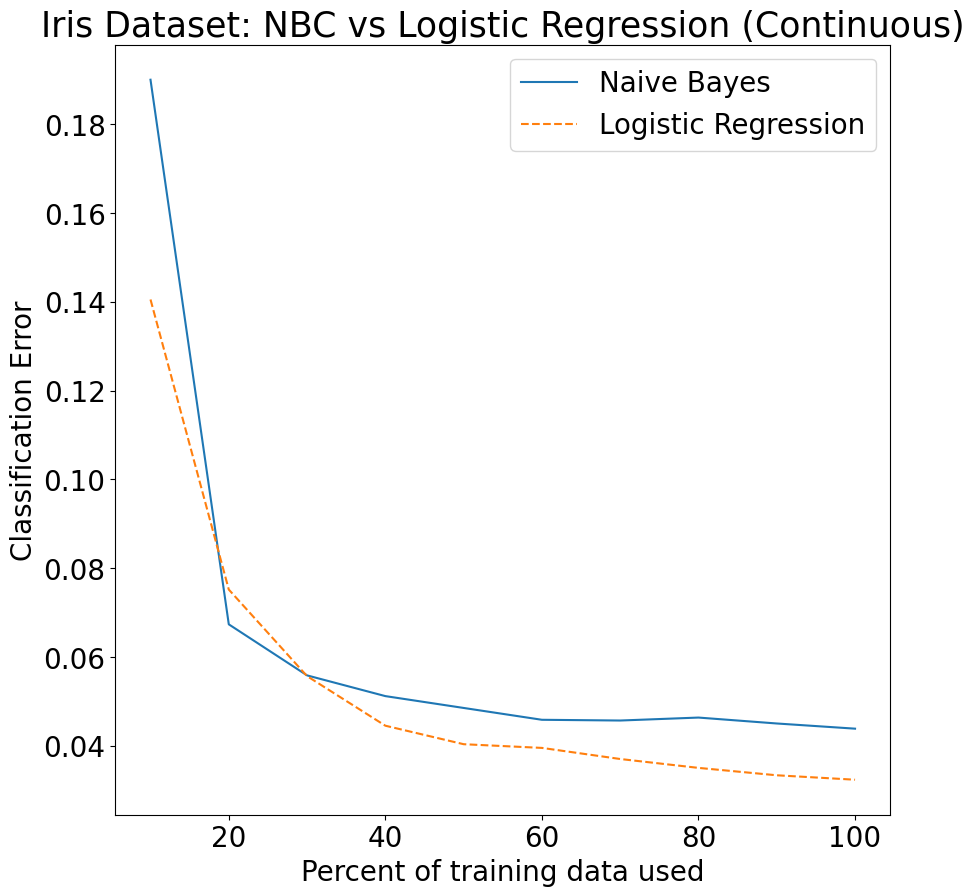

In [13]:
import warnings

# Suppress all FutureWarning exceptions during the experiment
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.datasets import load_iris

# Load the data
iris = load_iris()
X = iris['data']
y = iris['target']

# Prepare the data
## Check if there is missing data
if np.isnan(X).any():
    print("Warning: Missing values found in Iris dataset.")
else:
    print("No missing values found in X.")
    
## Check the feature type
if np.issubdtype(X.dtype, np.number) and not np.issubdtype(X.dtype, np.integer):
    print("All features (X) are continuous (float). No encoding needed.")
else:
    print("Warning: X features are not float type.")
    
if np.issubdtype(y.dtype, np.integer):
    print("Labels (y) are integers. No label encoding needed.")
else:
    print("Warning: Y labels are not integer type.")

# Print the first five rows of the prepared data
print("First 5 rows of X:")
print(pd.DataFrame(X, columns=iris.feature_names).head())
print("\nFirst 5 labels (y):")
print(y[:5])

# Initialization of our two models
lr_model = LogisticRegression(solver='lbfgs', multi_class='multinomial', random_state=42, max_iter=2000)
nbc_model = NBC(feature_types=['r', 'r', 'r', 'r'])

# We run the experiment 200 times for averaging
nbc_errors, lr_errors = compareNBCvsLR(
    nbc_model,
    lr_model,
    X,
    y,
    num_runs=200,
    num_splits=10
)

# Plot the learning curves
makePlot(
    nbc_errors,
    lr_errors,
    title='Iris Dataset: NBC vs Logistic Regression (Continuous)',
    num_splits=10
)


**Dataset 2: Voting Dataset**

https://archive.ics.uci.edu/ml/datasets/congressional+voting+records

The logistic regression line meets the naive bayes line early in the plot. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       435 non-null    object
 1   1       423 non-null    object
 2   2       387 non-null    object
 3   3       424 non-null    object
 4   4       424 non-null    object
 5   5       420 non-null    object
 6   6       424 non-null    object
 7   7       421 non-null    object
 8   8       420 non-null    object
 9   9       413 non-null    object
 10  10      428 non-null    object
 11  11      414 non-null    object
 12  12      404 non-null    object
 13  13      410 non-null    object
 14  14      418 non-null    object
 15  15      407 non-null    object
 16  16      331 non-null    object
dtypes: object(17)
memory usage: 57.9+ KB
Missing values imputed with the mode.
Features encoded from 'y'/'n' to 1/0.
Labels encoded to ['democrat' 'republican'].

--- Prepared Voting Dataset ---
First 5 rows of

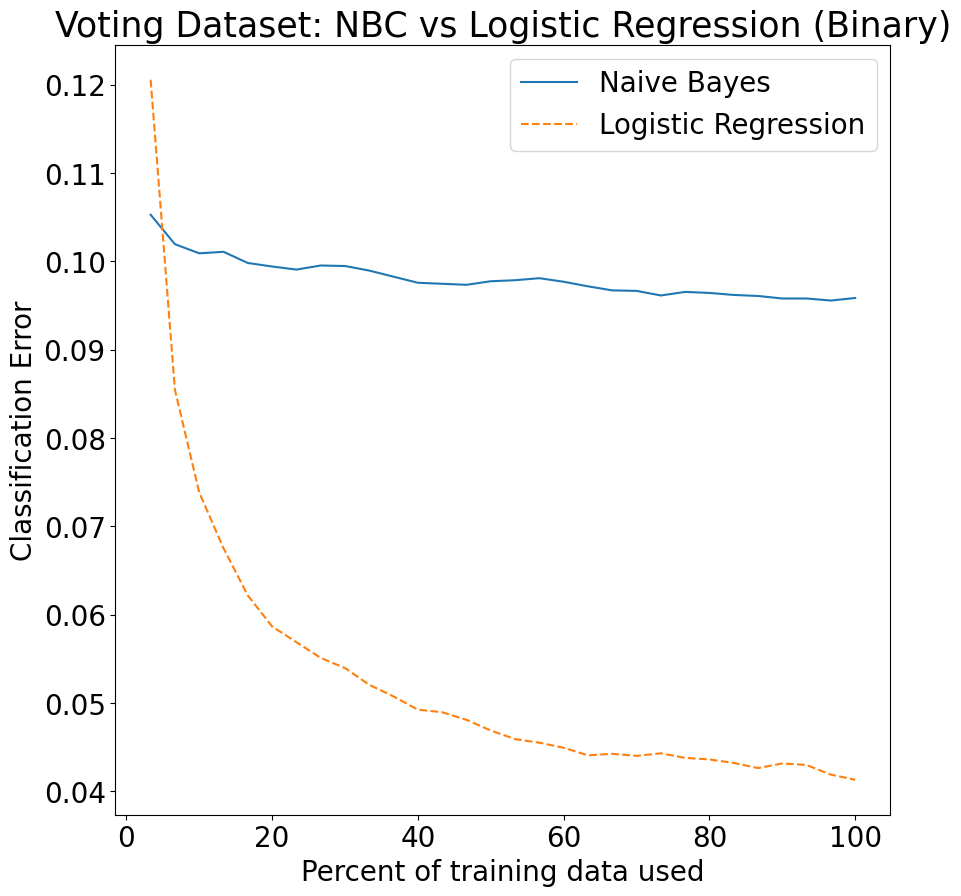

In [14]:
from sklearn.preprocessing import LabelEncoder

# Load the data and separate X and y
voting = pd.read_csv('voting.csv', header=None, skiprows=1)
voting.info()
X_raw = voting.iloc[:,1:]
y_raw = voting.iloc[:, 0]

# Impute the missing values by filling NaN values with the mode (most frewuent value) because the features are binary/categorical
X_imputed = X_raw.apply(lambda col: col.fillna(col.mode()[0]))
print("Missing values imputed with the mode.")

# Encode the binary categorical features ('y'/'n') to integers (1/0).
# This is safe because binary features are considered ordinal for this task.
X_encoded = X_imputed.replace({'y':1, 'n':0})
print("Features encoded from 'y'/'n' to 1/0.")

# Convert to final NumPy array X (used for printing and training)
X2 = X_encoded.to_numpy().astype(int)

# Encode the labels y from strings to integers (1/0).
le = LabelEncoder()
y2 = le.fit_transform(y_raw)
print(f"Labels encoded to {le.classes_}.")

# Print the first five rows of the prepared data
print("\n--- Prepared Voting Dataset ---")
print("First 5 rows of X (Imputed and Encoded 0/1):")
print(X2[:5])
print("\nFirst 5 labels (y):")
print(y2[:5])

# Initialization of our two models
lr_model2 = LogisticRegression(solver='lbfgs', multi_class='auto', random_state=42, max_iter=500)
nbc_model2 = NBC(feature_types=['b']*16)

# We run the experiment 200 times for averaging
nbc_errors2, lr_errors2 = compareNBCvsLR(
    nbc_model2,
    lr_model2,
    X2,
    y2,
    num_runs=200,
    num_splits=30
)

# Plot the learning curves
makePlot(
    nbc_errors2, 
    lr_errors2, 
    title='Voting Dataset: NBC vs Logistic Regression (Binary)', 
    num_splits=30
)


**Dataset 3: Breast Cancer Dataset (Bonus Tasks)**

https://archive.ics.uci.edu/ml/datasets/breast+cancer

The dataset has continues, binary and categorical features. It also has missing values.

Hints: You can precompute the size of the domains of the categorical features.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       286 non-null    object
 1   1       286 non-null    object
 2   2       286 non-null    object
 3   3       286 non-null    object
 4   4       286 non-null    object
 5   5       278 non-null    object
 6   6       286 non-null    int64 
 7   7       286 non-null    object
 8   8       285 non-null    object
 9   9       286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB
Missing values imputed with the mode.
NBC features (9-dim) encoded.
Calculated NBC Domain Sizes: [6, 3, 11, 7, 2, 3, 2, 5, 2]
Labels encoded to ['no-recurrence-events' 'recurrence-events'].

--- Prepared Breast Cancer Dataset ---
First 5 rows of X (Encoded Integers):
[[1 2 5 0 0 2 0 1 0]
 [2 2 3 0 0 1 1 4 0]
 [2 2 3 0 0 1 0 1 0]
 [4 0 2 0 0 1 1 2 0]
 [2 2 0 0 0 1 1 3 0]]

First 5 labels (y):
[0 0 0 0 0]
-----

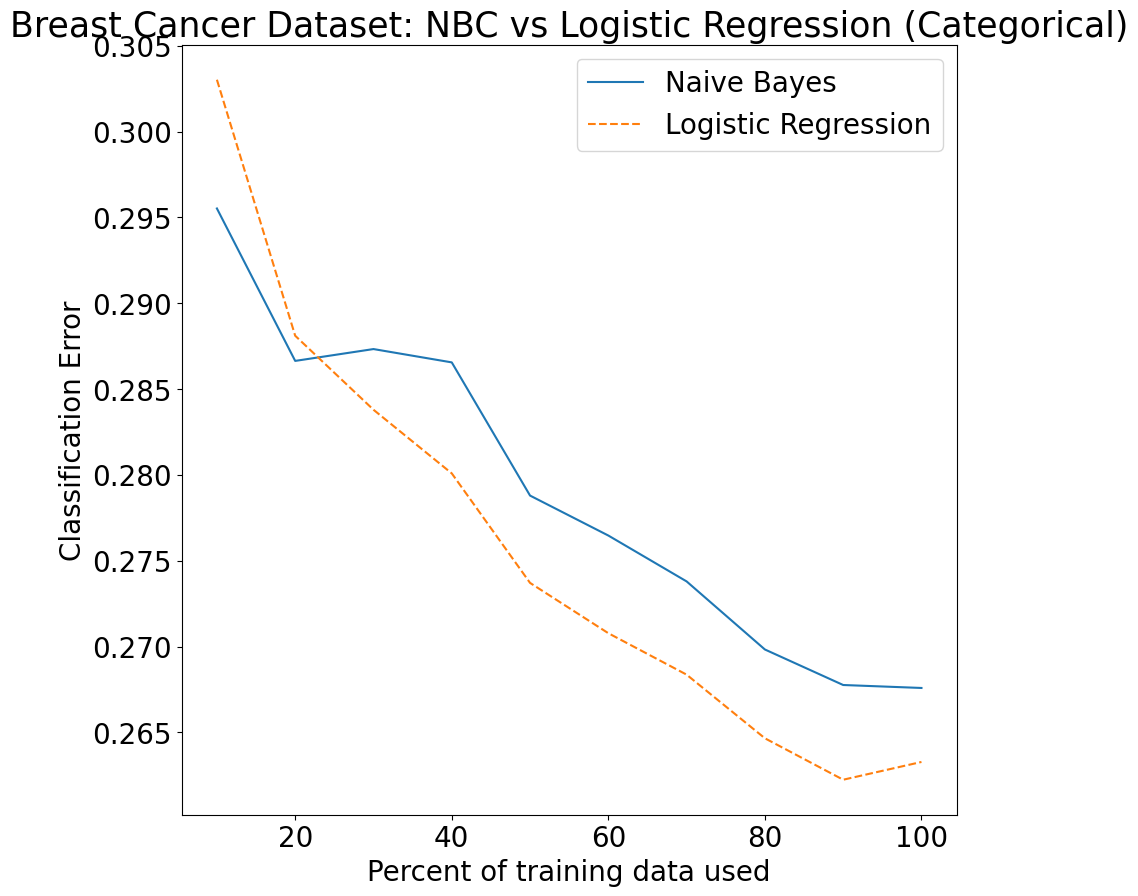

In [15]:
# Load the data and separate X and y
cancer = pd.read_csv('breast-cancer.csv', header=None, na_values=['?'], skiprows=1)
cancer.info()
X_raw2 = cancer.iloc[:, 1:]
y_raw2 = cancer.iloc[:, 0]

# Impute missing '?' values with the mode (most frequent category) again
X_imputed2 = X_raw2.apply(lambda col: col.fillna(col.mode()[0]))
print("Missing values imputed with the mode.")

# Encode all categorical features to unique integers (0, 1, 2, ...)
X_encoded2_common = X_imputed2.apply(LabelEncoder().fit_transform)
X3_NBC = X_encoded2_common.to_numpy().astype(int)
print("NBC features (9-dim) encoded.")

# Define the columns that need one-hot encoding
nominal_cols = [4, 6, 8]
ordinal_cols = [0, 1, 2, 3, 5, 7]

# Separate the nominal features
X_nominal = X_imputed2.iloc[:, nominal_cols]
X_ordinal = X_imputed2.iloc[:, ordinal_cols]

# One-hot encode the nominal features
X_onehot = pd.get_dummies(X_nominal, drop_first=True, dtype=int)

# Integer encode ordinal / simple numerical features
le_ordinal = LabelEncoder()
X_ordinal_encoded = X_ordinal.apply(le_ordinal.fit_transform)

# Create the final final LR feature matrix
X3_LR = pd.concat([X_onehot, X_ordinal_encoded], axis=1).to_numpy()
D_LR = X3_LR.shape[1]

# Calculate the domain size for NBC initialization (uses X3_NBC)
num_categories_list = (X3_NBC.max(axis=0) + 1).tolist()
print(f"Calculated NBC Domain Sizes: {num_categories_list}") 

# Encode the labels y
le_y = LabelEncoder()
y3 = le_y.fit_transform(y_raw2)
print(f"Labels encoded to {le_y.classes_}.")

# Print the first 5 rows of the prepared data
print("\n--- Prepared Breast Cancer Dataset ---")
print("First 5 rows of X (Encoded Integers):")
print(X3_NBC[:5])
print("\nFirst 5 labels (y):")
print(y3[:5])
print("--------------------------------------")

# Initialization of our two models (stronger regularization for LR to reduce test error)
lr_model3 = LogisticRegression(solver='lbfgs', multi_class='multinomial', random_state=42, max_iter=500, C=0.1)
nbc_model3 = NBC(feature_types=['c']*9, num_of_categories_list=num_categories_list)

# We have to run the experiments separately because we have two different feature matrices for both models
# NBC experiment (X3_NBC as the X input)
nbc_errors3, _ = compareNBCvsLR(
    nbc_model3,
    None, 
    X3_NBC,
    y3,
    num_runs=200,
    num_splits=10
)

# LR experiment (Use X3_LR as the X input)

_, lr_errors3_final = compareNBCvsLR(
    None,
    lr_model3, 
    X3_LR,
    y3,
    num_runs=200,
    num_splits=10
)

# Plot the learning curves
makePlot(
    nbc_errors3,
    lr_errors3_final,
    title='Breast Cancer Dataset: NBC vs Logistic Regression (Categorical)',
    num_splits=10
)
